# NAC Banded Antisymmetric Relaxation Time

This notebook is the control panel for banded antisymmetric NAC/contact relaxation analyses.

- Existing CSV files are loaded first, so plotting does not recalculate trajectories.
- Banded antisymmetric residue pairs satisfy `abs(resid_i + resid_j - target) < window`.
- The default target is the residue-range endpoints sum, for example NAC uses `61 + 95 = 156`.
- Set `SURVIVAL_FORCE_RECALCULATE` or `ACF_FORCE_RECALCULATE` to `True` only when you want to rebuild the raw CSV data.
- Final plotting style is centralized in `nac_plotting.py` and follows the original `Analysis/NAC_contact_lifetime/NAC_contact_relaxation_time` notebook.
- `SHARED_SCAN` and `USE_VALID_CHAIN_CACHE` speed up calculation without changing `SKIP_FRAME`.


## Setup


In [1]:
from __future__ import annotations

import contextlib
import importlib
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib-cache"))

import pandas as pd
from IPython.display import display


def find_nac_dir():
    folder_name = "NAC_banded_antisymmetric_contact_relaxation_time"
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / folder_name,
        cwd / "NAC_contact_survival" / folder_name,
        cwd / "Analysis" / "NAC_contact_survival" / folder_name,
        cwd / "Analysis" / folder_name,
        cwd.parent / "NAC_contact_survival" / folder_name,
        cwd.parent / folder_name,
    ]
    for candidate in candidates:
        if (candidate / "nac_triplet_relaxation.py").exists():
            return candidate
    raise FileNotFoundError(
        f"Cannot find {folder_name} under Analysis/NAC_contact_survival paths. paths."
    )

NAC_DIR = find_nac_dir()
if str(NAC_DIR) not in sys.path:
    sys.path.insert(0, str(NAC_DIR))

import nac_triplet_relaxation
import nac_triplet_acf
import nac_plotting

importlib.reload(nac_triplet_relaxation)
importlib.reload(nac_triplet_acf)
importlib.reload(nac_plotting)

print(f"NAC banded antisymmetric analysis directory: {NAC_DIR}")
print(f"Project root inferred by script: {nac_triplet_relaxation.PROJECT_ROOT}")


/home/jychen/anaconda3/envs/CJY/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NAC banded antisymmetric analysis directory: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time
Project root inferred by script: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP


## Parameters


In [2]:

GROUPS = nac_triplet_relaxation.DEFAULT_GROUPS
GROUP_LABELS = nac_plotting.default_group_labels(GROUPS)
GROUP_COLORS = nac_plotting.default_group_colors(GROUPS)
CONTACT_MODES = nac_triplet_relaxation.DEFAULT_CONTACT_MODES

RUN_SURVIVAL = True
RUN_CONTACT_ACF = True
COMPUTE_IF_MISSING = True

SURVIVAL_FORCE_RECALCULATE = False
ACF_FORCE_RECALCULATE = False

CONTACT_CUTOFF_NM = 0.8
ANTISYMMETRIC_SUM_TARGET = None  # None = residue_range_start + residue_range_end
ANTISYMMETRIC_SUM_WINDOW = 8.0
CHAIN_FILTER_METHOD = "largest_cluster"
CLUSTER_DIST_CUTOFF_A = 8.0
RADIUS_LIMIT_NM = 10.0
USE_RADIUS_FILTER = CHAIN_FILTER_METHOD == "radius"
END_FRAME = -1
SKIP_FRAME = 1
PROGRESS_EVERY = 100

SURVIVAL_XLIM_NS = 20.0
ACF_MAX_LAG_NS = 2000.0
ACF_PLOT_XLIM_NS = 2000.0
ACF_KIND = "fluctuation"
ACF_PAIR_CHUNK = 128
SHARED_SCAN = True
USE_VALID_CHAIN_CACHE = True
VALID_CHAIN_CACHE_DIR = NAC_DIR / "valid_chain_cache"
SURVIVAL_REGIONS = ("NAC",)
ACF_REGIONS = ("NAC",)

print("Groups:")
for group in GROUPS:
    print(f"  {group['name']}: {len(group['trajectories'])} trajectories")
print("Group colors:")
for group in GROUPS:
    print(f"  {GROUP_LABELS[group['name']]}: {GROUP_COLORS[group['name']]}")
print(f"Chain filter: {CHAIN_FILTER_METHOD}; largest-cluster BB cutoff: {CLUSTER_DIST_CUTOFF_A:g} A")
print(f"Banded antisymmetric target: {ANTISYMMETRIC_SUM_TARGET}; window: {ANTISYMMETRIC_SUM_WINDOW:g}")
print(f"ACF target lag: {ACF_MAX_LAG_NS:g} ns; plotting range: 0-{ACF_PLOT_XLIM_NS:g} ns")
print(f"Shared scan: {SHARED_SCAN}; valid-chain cache: {USE_VALID_CHAIN_CACHE}")
print(f"Valid-chain cache directory: {VALID_CHAIN_CACHE_DIR}")


Groups:
  G1_Wcluster_alhx0: 3 trajectories
  G2_Wcluster_alhx700: 3 trajectories
  G3_Onmem_plus: 3 trajectories
  G4_Onmem_wall: 3 trajectories
Group colors:
  $\mathrm{IDP}_{50}$: #4C78A8
  $\mathrm{Hel}_{50}$: #F58518
  $\mathrm{IDP}_{50}$-Mem: #54A24B
  $\mathrm{Hel}_{10}\mathrm{IDP}_{40}$-Mem: #B279A2
Chain filter: largest_cluster; largest-cluster BB cutoff: 8 A
Banded antisymmetric target: None; window: 8
ACF target lag: 2000 ns; plotting range: 0-2000 ns
Shared scan: True; valid-chain cache: True
Valid-chain cache directory: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time/valid_chain_cache


## Existing Data


In [3]:
summary_paths = {
    "NAC survival": NAC_DIR / "nac_contact_outputs" / "nac_contact_mode_relaxation_summary.csv",
    "NAC ACF": NAC_DIR / "nac_contact_acf_outputs" / "nac_contact_mode_acf_summary.csv",
}

for label, path in summary_paths.items():
    print(f"{label}: {path if path.exists() else 'missing'}")
    if path.exists():
        display(pd.read_csv(path).head())


NAC survival: missing
NAC ACF: missing


## Load Or Compute Helpers


In [4]:

CONTACT_REGION_SPECS = {
    "NAC": {
        "label": "NAC",
        "slug": "nac",
        "observable_token": "NAC",
        "residue_range": (61, 95),
        "survival_output_dir": NAC_DIR / "nac_contact_outputs",
        "acf_output_dir": NAC_DIR / "nac_contact_acf_outputs",
    },
}


def region_contact_mode_config(region_label, slug, observable_token):
    return {
        "any_nac_to_nac_bb": {
            "label": f"Any {region_label} BB to {region_label} BB",
            "observable": f"{observable_token}_any_to_{observable_token}_BB_contact_survival",
            "file_prefix": f"{slug}_any_{slug}_to_{slug}_bb",
            "event_unit": "chain_pair",
        },
        "three_antisymmetric_nac_bb": {
            "label": f"Any 3 banded anti-par. {region_label} BB",
            "observable": f"{observable_token}_three_antisymmetric_BB_contact_survival",
            "file_prefix": f"{slug}_three_antisymmetric_bb",
            "event_unit": "chain_pair",
        },
        "antisymmetric_nac_bb": {
            "label": f"Any 1 banded anti-par. {region_label} BB",
            "observable": f"{observable_token}_antisymmetric_BB_contact_survival",
            "file_prefix": f"{slug}_antisymmetric_bb",
            "event_unit": "chain_pair",
        },
        "triplet_antisymmetric_nac_bb": {
            "label": f"3 consecutive banded anti-par. {region_label} BB",
            "observable": f"{observable_token}_triplet_antisymmetric_BB_contact_survival",
            "file_prefix": f"{slug}_triplet_antisymmetric_bb",
            "event_unit": "chain_pair",
        },
    }


@contextlib.contextmanager
def temporary_region_contact_modes(region_label, slug, observable_token):
    config = nac_triplet_relaxation.CONTACT_MODE_CONFIG
    original = {mode: dict(config[mode]) for mode in CONTACT_MODES}
    try:
        for mode, cfg in region_contact_mode_config(region_label, slug, observable_token).items():
            config[mode].update(cfg)
        yield
    finally:
        for mode, cfg in original.items():
            config[mode].clear()
            config[mode].update(cfg)


def cached_filter_matches(summary):
    method = nac_triplet_relaxation.resolve_chain_filter_method(
        use_radius_filter=USE_RADIUS_FILTER,
        chain_filter_method=CHAIN_FILTER_METHOD,
    )
    return nac_triplet_relaxation.cache_matches_chain_filter(
        summary,
        method,
        cluster_dist_cutoff_A=CLUSTER_DIST_CUTOFF_A,
        radius_limit_A=RADIUS_LIMIT_NM * 10.0,
    )


def cached_acf_lag_matches(results):
    for mode in CONTACT_MODES:
        df = results.get(mode, {}).get("data", pd.DataFrame())
        if df.empty or "time_ps" not in df:
            return False
        if float(df["time_ps"].max()) + 1e-9 < ACF_MAX_LAG_NS * 1000.0:
            return False
    return True


def load_or_compute_survival_region(region_key):
    spec = CONTACT_REGION_SPECS[region_key]
    output_dir = spec["survival_output_dir"]
    results, summary, complete = nac_plotting.load_cached_survival(output_dir, CONTACT_MODES)
    if complete and not SURVIVAL_FORCE_RECALCULATE and cached_filter_matches(summary):
        print(f"Loaded cached {spec['label']} contact survival CSV files; trajectory calculation skipped.")
        return results, summary
    if not COMPUTE_IF_MISSING and not SURVIVAL_FORCE_RECALCULATE:
        print(f"{spec['label']} survival cache is incomplete or uses old filtering/definition; computation disabled.")
        return results, summary

    print(
        f"Computing {spec['label']} contact survival CSV files, residues "
        f"{spec['residue_range'][0]}-{spec['residue_range'][1]}..."
    )
    with temporary_region_contact_modes(spec["label"], spec["slug"], spec["observable_token"]):
        return nac_triplet_relaxation.run_nac_contact_relaxation_comparison(
            contact_modes=CONTACT_MODES,
            combined_summary_csv=f"{spec['slug']}_contact_mode_relaxation_summary.csv",
            groups=GROUPS,
            group_labels=GROUP_LABELS,
            group_colors=GROUP_COLORS,
            radius_limit_A=RADIUS_LIMIT_NM * 10.0,
            end_frame=END_FRAME,
            skip_frame=SKIP_FRAME,
            progress_every=PROGRESS_EVERY,
            output_dir=str(output_dir),
            contact_cutoff_nm=CONTACT_CUTOFF_NM,
            use_radius_filter=USE_RADIUS_FILTER,
            chain_filter_method=CHAIN_FILTER_METHOD,
            cluster_dist_cutoff_A=CLUSTER_DIST_CUTOFF_A,
            force=SURVIVAL_FORCE_RECALCULATE,
            nac_residue_range=spec["residue_range"],
            antisymmetric_sum_target=ANTISYMMETRIC_SUM_TARGET,
            antisymmetric_sum_window=ANTISYMMETRIC_SUM_WINDOW,
            shared_scan=SHARED_SCAN,
            use_valid_chain_cache=USE_VALID_CHAIN_CACHE,
            valid_chain_cache_dir=str(VALID_CHAIN_CACHE_DIR),
        )


def load_or_compute_acf_region(region_key):
    spec = CONTACT_REGION_SPECS[region_key]
    results, summary, complete = nac_plotting.load_cached_acf(spec["acf_output_dir"], CONTACT_MODES)
    if complete and not ACF_FORCE_RECALCULATE and cached_filter_matches(summary) and cached_acf_lag_matches(results):
        print(f"Loaded cached {spec['label']} contact ACF CSV files; trajectory calculation skipped.")
        return results, summary
    if not COMPUTE_IF_MISSING and not ACF_FORCE_RECALCULATE:
        print(f"{spec['label']} ACF cache is incomplete or uses old filtering/definition; computation disabled.")
        return results, summary

    print(
        f"Computing {spec['label']} contact ACF CSV files, residues "
        f"{spec['residue_range'][0]}-{spec['residue_range'][1]}..."
    )
    with temporary_region_contact_modes(spec["label"], spec["slug"], spec["observable_token"]):
        return nac_triplet_acf.run_nac_contact_acf_comparison(
            contact_modes=CONTACT_MODES,
            combined_summary_csv=f"{spec['slug']}_contact_mode_acf_summary.csv",
            groups=GROUPS,
            group_labels=GROUP_LABELS,
            group_colors=GROUP_COLORS,
            radius_limit_A=RADIUS_LIMIT_NM * 10.0,
            end_frame=END_FRAME,
            skip_frame=SKIP_FRAME,
            progress_every=PROGRESS_EVERY,
            output_dir=str(spec["acf_output_dir"]),
            contact_cutoff_nm=CONTACT_CUTOFF_NM,
            use_radius_filter=USE_RADIUS_FILTER,
            chain_filter_method=CHAIN_FILTER_METHOD,
            cluster_dist_cutoff_A=CLUSTER_DIST_CUTOFF_A,
            force=ACF_FORCE_RECALCULATE,
            acf_kind=ACF_KIND,
            acf_pair_chunk=ACF_PAIR_CHUNK,
            max_lag_ns=ACF_MAX_LAG_NS,
            nac_residue_range=spec["residue_range"],
            antisymmetric_sum_target=ANTISYMMETRIC_SUM_TARGET,
            antisymmetric_sum_window=ANTISYMMETRIC_SUM_WINDOW,
            shared_scan=SHARED_SCAN,
            use_valid_chain_cache=USE_VALID_CHAIN_CACHE,
            valid_chain_cache_dir=str(VALID_CHAIN_CACHE_DIR),
        )


## Contact-Region Survival


Computing NAC contact survival CSV files, residues 61-95...
Processing shared antisymmetric survival scan: $\mathrm{IDP}_{50}$
Chain selection: all
  -> shared survival scan for 4 contact modes: clus_centered.xtc
     cluster frame 10001/10001
     saved valid-chain cache: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time/valid_chain_cache/valid_chains_355664102e3ca4d6a927b45c.npz
     contact frame 10001/10001
     Any NAC BB to NAC BB: events=86845, mean=0.0039 us, median=0.0020 us
     Any 3 banded antisymmetric NAC BB: events=36225, mean=0.0024 us, median=0.0010 us
     Any 1 banded antisymmetric NAC BB: events=51255, mean=0.0030 us, median=0.0020 us
     3 consecutive banded antisymmetric NAC BB: events=24581, mean=0.0018 us, median=0.0010 us
  -> shared survival scan for 4 contact modes: clus_centered.xtc
     cluster frame 10001/10001
     saved valid-chain 

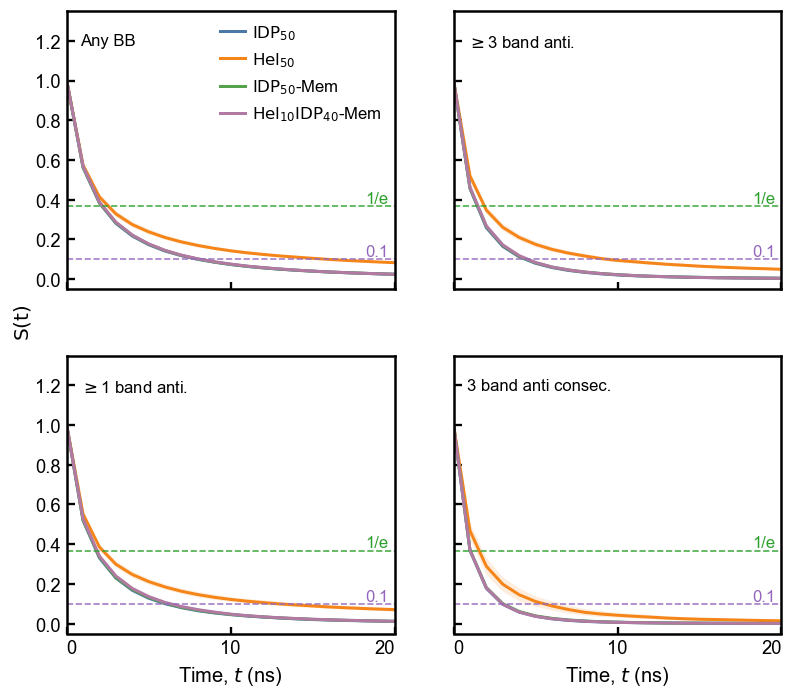

Figure context: NAC contact survival; x-axis = Time, $t$ (ns); y-axis = $\mathrm{S}(\mathrm{t})$
Saved final summary plot: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time/nac_contact_outputs/nac_contact_survival_final_summary.png


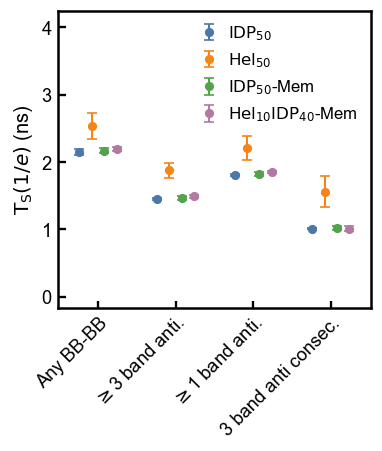

Figure context: NAC contact survival; threshold = 1/e; y-axis = $\mathrm{T}_{\mathrm{S}}(1/e)$ (ns)
Saved metric table: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time/nac_contact_outputs/nac_contact_survival_t_1e_summary.csv
Saved metric plot: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time/nac_contact_outputs/nac_contact_survival_t_1e_summary.png
Reached threshold: 16/16


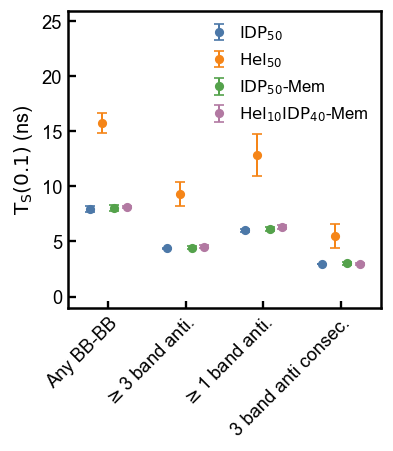

Figure context: NAC contact survival; threshold = 0.1; y-axis = $\mathrm{T}_{\mathrm{S}}(0.1)$ (ns)
Saved metric table: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time/nac_contact_outputs/nac_contact_survival_t_01_summary.csv
Saved metric plot: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time/nac_contact_outputs/nac_contact_survival_t_01_summary.png
Reached threshold: 16/16


,group,group_label,observable,contact_mode,contact_label,event_unit,chain_selection,chain_filter_method,n_events,mean_lifetime_ps,...,contact_cutoff_nm,antisymmetric_sum_target,antisymmetric_sum_window,cluster_dist_cutoff_A,radius_limit_A,nac_start,nac_end,triplet_size,banded_triplet_definition,region
0,G1_Wcluster_alhx0,$\mathrm{IDP}_{50}$,NAC_any_to_NAC_BB_contact_survival,any_nac_to_nac_bb,Any NAC BB to NAC BB,chain_pair,all,largest_cluster,251022,3894.063907,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
1,G2_Wcluster_alhx700,$\mathrm{Hel}_{50}$,NAC_any_to_NAC_BB_contact_survival,any_nac_to_nac_bb,Any NAC BB to NAC BB,chain_pair,all,largest_cluster,63714,13050.970730,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
2,G3_Onmem_plus,$\mathrm{IDP}_{50}$-Mem,NAC_any_to_NAC_BB_contact_survival,any_nac_to_nac_bb,Any NAC BB to NAC BB,chain_pair,all,largest_cluster,243525,3944.765297,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
3,G4_Onmem_wall,$\mathrm{Hel}_{10}\mathrm{IDP}_{40}$-Mem,NAC_any_to_NAC_BB_contact_survival,any_nac_to_nac_bb,Any NAC BB to NAC BB,chain_pair,last_40,largest_cluster,154868,3944.328508,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
4,G1_Wcluster_alhx0,$\mathrm{IDP}_{50}$,NAC_three_antisymmetric_BB_contact_survival,three_antisymmetric_nac_bb,Any 3 banded antisymmetric NAC BB,chain_pair,all,largest_cluster,104821,2367.157833,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
5,G2_Wcluster_alhx700,$\mathrm{Hel}_{50}$,NAC_three_antisymmetric_BB_contact_survival,three_antisymmetric_nac_bb,Any 3 banded antisymmetric NAC BB,chain_pair,all,largest_cluster,31498,8756.711949,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
6,G3_Onmem_plus,$\mathrm{IDP}_{50}$-Mem,NAC_three_antisymmetric_BB_contact_survival,three_antisymmetric_nac_bb,Any 3 banded antisymmetric NAC BB,chain_pair,all,largest_cluster,103741,2401.359594,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
7,G4_Onmem_wall,$\mathrm{Hel}_{10}\mathrm{IDP}_{40}$-Mem,NAC_three_antisymmetric_BB_contact_survival,three_antisymmetric_nac_bb,Any 3 banded antisymmetric NAC BB,chain_pair,last_40,largest_cluster,67687,2409.140906,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
8,G1_Wcluster_alhx0,$\mathrm{IDP}_{50}$,NAC_antisymmetric_BB_contact_survival,antisymmetric_nac_bb,Any 1 banded antisymmetric NAC BB,chain_pair,all,largest_cluster,147495,3051.411904,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
9,G2_Wcluster_alhx700,$\mathrm{Hel}_{50}$,NAC_antisymmetric_BB_contact_survival,antisymmetric_nac_bb,Any 1 banded antisymmetric NAC BB,chain_pair,all,largest_cluster,36427,11771.551308,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC


In [5]:

survival_outputs = {}
survival_summary_tables = []
survival_metric_tables = []

if RUN_SURVIVAL:
    for region_key in SURVIVAL_REGIONS:
        spec = CONTACT_REGION_SPECS[region_key]
        results, summary = load_or_compute_survival_region(region_key)
        final_plot = nac_plotting.plot_decay_final_summary(
            results,
            mean_col="survival_mean",
            std_col="survival_std",
            output_dir=spec["survival_output_dir"],
            file_prefix=f"{spec['slug']}_contact_survival",
            ylabel=r"$\mathrm{S}(\mathrm{t})$",
            xlabel="Time, $t$ (ns)",
            xlim_ns=SURVIVAL_XLIM_NS,
            contact_modes=CONTACT_MODES,
            groups=GROUPS,
            group_labels=GROUP_LABELS,
            group_colors=GROUP_COLORS,
            y_min=-0.05,
        )
        metric_tables = nac_plotting.plot_threshold_set(
            results,
            mean_col="survival_mean",
            std_col="survival_std",
            output_dir=spec["survival_output_dir"],
            file_prefix=f"{spec['slug']}_contact_survival",
            contact_modes=CONTACT_MODES,
            groups=GROUPS,
            group_labels=GROUP_LABELS,
            group_colors=GROUP_COLORS,
        )
        survival_outputs[region_key] = {
            "results": results,
            "summary": summary,
            "final_plot": final_plot,
            "metric_tables": metric_tables,
        }
        if not summary.empty:
            survival_summary_tables.append(summary.assign(region=region_key))
        for metric_name, metric_df in metric_tables.items():
            survival_metric_tables.append(metric_df.assign(region=region_key, metric=metric_name))

    if survival_summary_tables:
        survival_summary = pd.concat(survival_summary_tables, ignore_index=True)
        display(survival_summary)
else:
    print("RUN_SURVIVAL is False; skipped.")


## Contact-Region ACF


Computing NAC contact ACF CSV files, residues 61-95...
Processing shared antisymmetric fluctuation ACF scan: $\mathrm{IDP}_{50}$
Chain selection: all
  -> shared ACF contact-series scan for 4 contact modes: clus_centered.xtc
     loaded valid-chain cache: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time/valid_chain_cache/valid_chains_355664102e3ca4d6a927b45c.npz
     contact-series memory estimate: 0.04 GiB
     contact frame 10001/10001
     Any NAC BB to NAC BB: contact_probability=0.028764, contact_observations=338294, variable_pairs=812
     Any 3 banded antisymmetric NAC BB: contact_probability=0.007309, contact_observations=85960, variable_pairs=654
     Any 1 banded antisymmetric NAC BB: contact_probability=0.013242, contact_observations=155745, variable_pairs=725
     3 consecutive banded antisymmetric NAC BB: contact_probability=0.003843, contact_observat

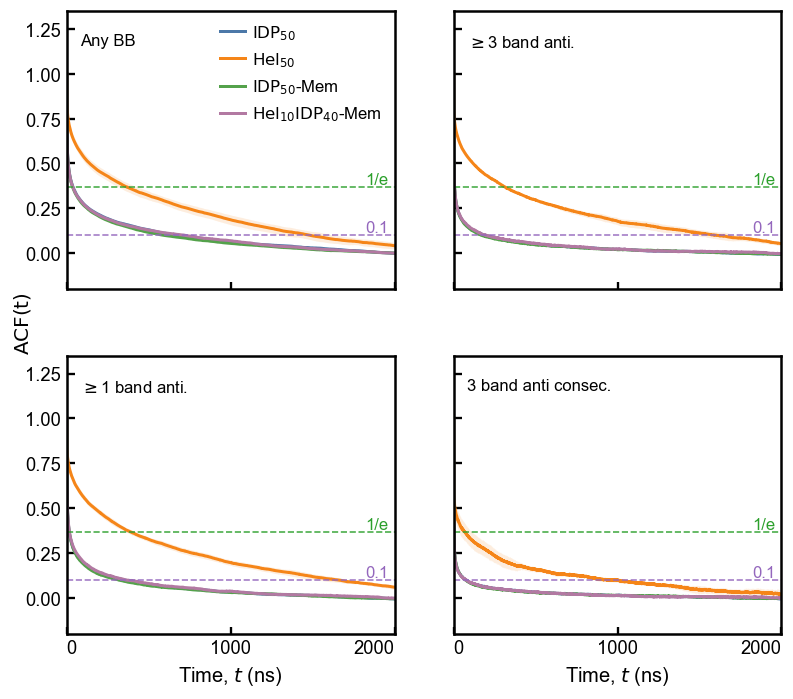

Figure context: NAC contact ACF; x-axis = Time, $t$ (ns); y-axis = $\mathrm{ACF}(\mathrm{t})$
Saved final summary plot: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time/nac_contact_acf_outputs/nac_contact_acf_final_summary.png


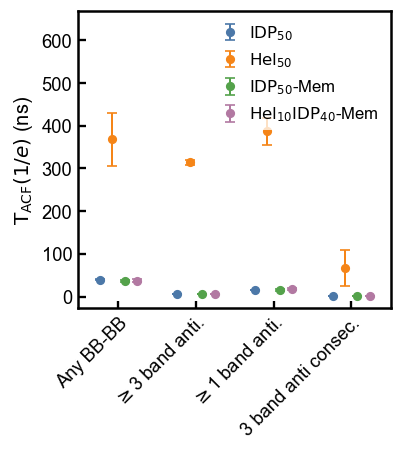

Figure context: NAC contact ACF; threshold = 1/e; y-axis = $\mathrm{T}_{\mathrm{ACF}}(1/e)$ (ns)
Saved metric table: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time/nac_contact_acf_outputs/nac_contact_acf_t_1e_summary.csv
Saved metric plot: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time/nac_contact_acf_outputs/nac_contact_acf_t_1e_summary.png
Reached threshold: 16/16


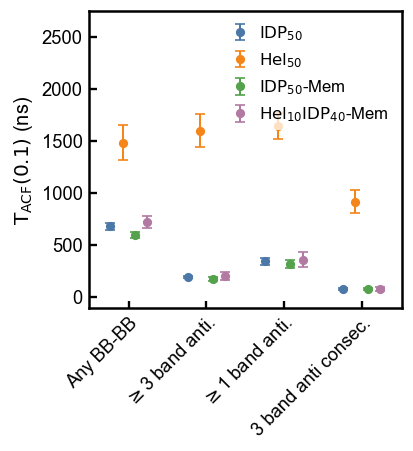

Figure context: NAC contact ACF; threshold = 0.1; y-axis = $\mathrm{T}_{\mathrm{ACF}}(0.1)$ (ns)
Saved metric table: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time/nac_contact_acf_outputs/nac_contact_acf_t_01_summary.csv
Saved metric plot: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time/nac_contact_acf_outputs/nac_contact_acf_t_01_summary.png
Reached threshold: 16/16


,group,group_label,observable,contact_mode,contact_label,acf_kind,event_unit,chain_selection,chain_filter_method,n_observations,...,contact_cutoff_nm,antisymmetric_sum_target,antisymmetric_sum_window,cluster_dist_cutoff_A,radius_limit_A,nac_start,nac_end,triplet_size,banded_triplet_definition,region
0,G1_Wcluster_alhx0,$\mathrm{IDP}_{50}$,NAC_any_to_NAC_BB_contact_fluctuation_acf,any_nac_to_nac_bb,Any NAC BB to NAC BB,fluctuation,chain_pair,all,largest_cluster,31573157,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
1,G2_Wcluster_alhx700,$\mathrm{Hel}_{50}$,NAC_any_to_NAC_BB_contact_fluctuation_acf,any_nac_to_nac_bb,Any NAC BB to NAC BB,fluctuation,chain_pair,all,largest_cluster,28842884,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
2,G3_Onmem_plus,$\mathrm{IDP}_{50}$-Mem,NAC_any_to_NAC_BB_contact_fluctuation_acf,any_nac_to_nac_bb,Any NAC BB to NAC BB,fluctuation,chain_pair,all,largest_cluster,27952795,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
3,G4_Onmem_wall,$\mathrm{Hel}_{10}\mathrm{IDP}_{40}$-Mem,NAC_any_to_NAC_BB_contact_fluctuation_acf,any_nac_to_nac_bb,Any NAC BB to NAC BB,fluctuation,chain_pair,last_40,largest_cluster,14821482,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
4,G1_Wcluster_alhx0,$\mathrm{IDP}_{50}$,NAC_three_antisymmetric_BB_contact_fluctuation...,three_antisymmetric_nac_bb,Any 3 banded antisymmetric NAC BB,fluctuation,chain_pair,all,largest_cluster,31573157,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
5,G2_Wcluster_alhx700,$\mathrm{Hel}_{50}$,NAC_three_antisymmetric_BB_contact_fluctuation...,three_antisymmetric_nac_bb,Any 3 banded antisymmetric NAC BB,fluctuation,chain_pair,all,largest_cluster,28842884,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
6,G3_Onmem_plus,$\mathrm{IDP}_{50}$-Mem,NAC_three_antisymmetric_BB_contact_fluctuation...,three_antisymmetric_nac_bb,Any 3 banded antisymmetric NAC BB,fluctuation,chain_pair,all,largest_cluster,27952795,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
7,G4_Onmem_wall,$\mathrm{Hel}_{10}\mathrm{IDP}_{40}$-Mem,NAC_three_antisymmetric_BB_contact_fluctuation...,three_antisymmetric_nac_bb,Any 3 banded antisymmetric NAC BB,fluctuation,chain_pair,last_40,largest_cluster,14821482,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
8,G1_Wcluster_alhx0,$\mathrm{IDP}_{50}$,NAC_antisymmetric_BB_contact_fluctuation_acf,antisymmetric_nac_bb,Any 1 banded antisymmetric NAC BB,fluctuation,chain_pair,all,largest_cluster,31573157,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC
9,G2_Wcluster_alhx700,$\mathrm{Hel}_{50}$,NAC_antisymmetric_BB_contact_fluctuation_acf,antisymmetric_nac_bb,Any 1 banded antisymmetric NAC BB,fluctuation,chain_pair,all,largest_cluster,28842884,...,0.8,156.0,8.0,8.0,100.0,61,95,3,partner_consecutive_v2,NAC


In [6]:

acf_outputs = {}
acf_summary_tables = []
acf_metric_tables = []

if RUN_CONTACT_ACF:
    for region_key in ACF_REGIONS:
        spec = CONTACT_REGION_SPECS[region_key]
        results, summary = load_or_compute_acf_region(region_key)
        final_plot = nac_plotting.plot_decay_final_summary(
            results,
            mean_col="acf_mean",
            std_col="acf_std",
            output_dir=spec["acf_output_dir"],
            file_prefix=f"{spec['slug']}_contact_acf",
            ylabel=r"$\mathrm{ACF}(\mathrm{t})$",
            xlabel="Time, $t$ (ns)",
            xlim_ns=ACF_PLOT_XLIM_NS,
            contact_modes=CONTACT_MODES,
            groups=GROUPS,
            group_labels=GROUP_LABELS,
            group_colors=GROUP_COLORS,
            y_min=-0.2 if ACF_KIND == "fluctuation" else -0.05,
        )
        metric_tables = nac_plotting.plot_threshold_set(
            results,
            mean_col="acf_mean",
            std_col="acf_std",
            output_dir=spec["acf_output_dir"],
            file_prefix=f"{spec['slug']}_contact_acf",
            contact_modes=CONTACT_MODES,
            groups=GROUPS,
            group_labels=GROUP_LABELS,
            group_colors=GROUP_COLORS,
        )
        acf_outputs[region_key] = {
            "results": results,
            "summary": summary,
            "final_plot": final_plot,
            "metric_tables": metric_tables,
        }
        if not summary.empty:
            acf_summary_tables.append(summary.assign(region=region_key))
        for metric_name, metric_df in metric_tables.items():
            acf_metric_tables.append(metric_df.assign(region=region_key, metric=metric_name))

    if acf_summary_tables:
        acf_summary = pd.concat(acf_summary_tables, ignore_index=True)
        display(acf_summary)
else:
    print("RUN_CONTACT_ACF is False; skipped.")


## Output Files


In [7]:
output_roots = [
    NAC_DIR / "nac_contact_outputs",
    NAC_DIR / "nac_contact_acf_outputs",
]

for root in output_roots:
    print(root)
    if root.exists():
        for path in sorted(root.glob("*summary.csv")):
            print(f"  {path.name}")
        for path in sorted(root.glob("*summary.png")):
            print(f"  {path.name}")


/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time/nac_contact_outputs
  nac_contact_mode_relaxation_summary.csv
  nac_contact_survival_t_01_summary.csv
  nac_contact_survival_t_1e_summary.csv
  nac_contact_survival_final_summary.png
  nac_contact_survival_t_01_summary.png
  nac_contact_survival_t_1e_summary.png
/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/NAC_contact_survival/NAC_banded_antisymmetric_contact_relaxation_time/nac_contact_acf_outputs
  nac_contact_acf_t_01_summary.csv
  nac_contact_acf_t_1e_summary.csv
  nac_contact_mode_acf_summary.csv
  nac_contact_acf_final_summary.png
  nac_contact_acf_t_01_summary.png
  nac_contact_acf_t_1e_summary.png
